# Week 10 - Unsupervised machine learning and magma storage pressures

One of the major topics in volcanology is determining the pressures, and therefore depths, at which magmas are stored beneath volcanoes. This information helps to interpret pre-eruptive warning signals (e.g., are seismic signals tracking magma movement or fluid circulation in an overlying hydrothermal system). Pinpointing magma storage depths is also critical for our understanding of mineral deposits - e.g., what are the conditions that allow them to form?

In this assignment we're going to look at some mineral data from the island of Floreana in the Galapagos Archipelago. While this isn't an active or particularly hazardous volcano it represents an interesting 'endmember' type of volcanic system as it erupts in highly energetic and explosive events every 20 - 30 thousand years (as shown by the types of volcanic deposits found on the island). Investigating these 'low activity' volcanoes helps us construct more genetic models of how magma systems form, and the underlying processes that control their characteristics.

![Galapagos Map](https://www.galapagos.org/wp-content/uploads/2022/05/Galapagos-Islands-Map-with-Islands-Names-copy-scaled.jpg)

![Floreana island](https://www.islandconservation.org/wp-content/uploads/2024/09/island-conservation-invasive-species-preventing-extinctions-floreana-island-coastline-feat-1.jpg)

Specifically we're going to look at the chemical data of a mineral known as clinopyroxene. Clinopyroxenes are typically characterised by the chemical formula $CaMgSi_2O_6$, but at high pressure incorporate small amounts of Na and Al into the structure ($NaAlSi_2O_6$). This allows us to use the composition of clinopyroxene to estimate the depth of magma storage - i.e., the clinopyroxene Na content records the pressure at which the crystal grew!

![clinopyroxene image](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQBnS7t_pc6YgMlvPhar_Nt7aw0h2grDu23Ew&s)

The problem, is that if the clinopyroxene didn't grow from the magma it erupted in, it cannot be used for these calculations! Secondary processes operating after initial crystal growth (i.e., chemical reactions taking place in the solid crust) can change the crystal chemistry, so we need to identify the crystals that grew directly from the magma. This is especially important at Floreana where clinopyroxene bearing 'xenoliths' (fragments of solid rocks unrelated to the erupted melt). We want to find a way to ensure that the loose clinopyroxene crystals separated from scoria flows on the island didn't originate within a xenolith and instead grew directly from the erupted melt.

One way to do this is through cluster analysis, a common form of unsupervised machine learning.

![Clustering Schematic](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

As with any and all assignments let's load in the required packages. In addition to our standard packages (Pandas, NumPy, matplotlib) we'll also load several types of clustering from sklearn as well as the ```StandardScaler``` class from the preprocessing submodule.

We will also load the ```dendrogram``` and ```linkage``` methods from scipy to help visualize the clusters.

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

## Exercise 1 - Examining apparent crystallization pressures

First, as in all notebooks, let's load in the data. Here we're loading in 550 analyses of clinopyroxenes from Floreana that I made during my PhD. As before, let's use the ```.head()``` method to inspect the DataFrame. This should reveal the presence of a column called `Type`.

In [223]:
# Load rock sample data
data = pd.read_excel('data/Floreana_clinopyroxene.xlsx')
data.head()

,Sample,Comment,Mineral,Session no.,Type,P_kbar,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,Cr2O3_Cpx,FeOt_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx
0,17MMSG16,16p4-1,cpx,1,Scoria,8.362149,49.8219,0.6661,7.0864,0.0442,7.2392,14.0366,20.0991,0.6960
1,17MMSG16,16p4-1,cpx,1,Scoria,8.440187,49.5610,0.6537,7.1702,0.0376,7.2306,13.8833,19.7857,0.6702
2,17MMSG16,16p4-1,cpx,1,Scoria,9.101004,50.3633,0.6602,7.1480,0.0602,7.0927,13.7663,19.8640,0.7156
3,17MMSG16,16p4-2,cpx,1,Scoria,9.174600,49.8030,0.6479,7.3362,0.0258,7.2627,13.8473,19.7837,0.7424
4,17MMSG16,16p4-2,cpx,1,Scoria,8.767960,50.2693,0.6639,7.3752,0.0317,7.1847,13.8933,19.7704,0.6709


This `Type` indicates where I found (and measured) each clinopyroxene. Samples with `data['Type'] == 'Scoria'` were found as loose crystals within the lava and *might* represent crystals that grew directly from the erupted melt. Let's use the `.unique()` method to look at what other types are listed in this dataset.

In [224]:
data['Type'].unique()


array(['Scoria', 'Wehrlite', 'Dunite', 'Gabbro'], dtype=object)

You should see 'Wehrlite', 'Dunite', and 'Gabbro' listed. These are all types of clinopyroxene bearing xenoliths.

What we can do first is calculate the 'apparent' crystallization pressure for all clinopyroxenes in the dataset. Create 4 histograms below using the kwarg `orientation="horizontal"` to display the estimated pressures for each `Type`. The pressures are calculated using the equation of Wang et al. (2021) using the Python library Thermobar, calculating pressures isn't the critical aspect of this assignment, but I can provide more information if anyone wants.

**(5 points)**

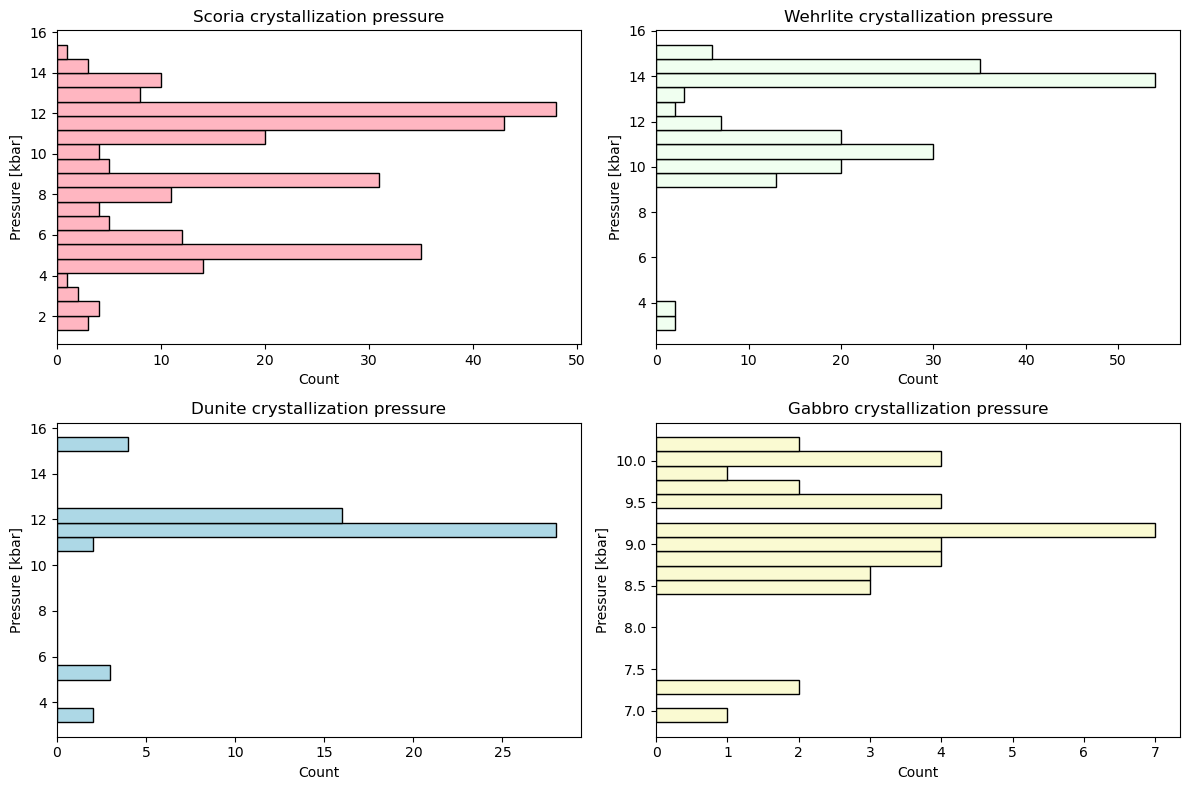

In [225]:
### Create a 4 panel plot of histrograms showing the estimated pressures for each `Type`
Scoria = data[data['Type']== 'Scoria']
Wehrlite = data[data['Type']== 'Wehrlite']
Dunite = data[data['Type']== 'Dunite']
Gabbro = data[data['Type']== 'Gabbro']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].hist(Scoria['P_kbar'], bins=20, ec='k', orientation="horizontal", color= 'lightpink')
axes[0, 0].set_title('Scoria crystallization pressure')

axes[0, 1].hist(Wehrlite['P_kbar'], bins=20, ec='k', orientation="horizontal", color= 'honeydew')
axes[0, 1].set_title('Wehrlite crystallization pressure')

axes[1, 0].hist(Dunite ['P_kbar'], bins=20, ec='k', orientation="horizontal", color= 'lightblue')
axes[1, 0].set_title('Dunite crystallization pressure')

axes[1, 1].hist(Gabbro['P_kbar'], bins=20, ec='k', orientation="horizontal", color='lightgoldenrodyellow')
axes[1, 1].set_title('Gabbro crystallization pressure')


for ax in axes.flat:
    ax.set_ylabel('Pressure [kbar]')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()


**(5 points)** What do you notice about the distribution of pressure in the scoria clinopyroxenes compared to the other three groups? 

The distribution of pressure in the scoria clinopyroxenes is more evenly distributed across all pressures. All three groups have their highest distribution between 8–15 kbar, but the other groups are also completely missing portions where the pressure is between 4–10 kbar. The other groups are not represetning any portion of kbar lower then 4 kbar in contrast to Scoria. Scoria is distributed continuously approx from 1-15 kbar.

**(5 points)** Beneath Isla Floreana the Moho (the boundary between the oceanic crust and mantle) is about 16 km deep, corresponding to a pressure of ~4.5 kbar. How does this compare to the results and why might this boundary represent a like magma stalling zone based on the image below (hint, look at the densities of the different regions)?

There is little to no data corresponding to pressures around 4.5 kbar. Magma rises through the mantle because it is more buoyant than the surrounding mantle rocks of 3.3 g/cm^3. However, as it reaches higher levels, it may no longer be buoyant enough to continue rising. The oceanic crust has a lower density at 2.9 g/cm^3. near the  Moho the magma can reach neutral buoyancy. As a result, the melt may not rise further and instead accumulates at this boundary. This zone therefore acts as a magma storage region. Because magma is stored instead of continuo to move up. Crystallization also may occur more slowly, which could explain the lack of data at  4.5 kbar.

![Crustal Structure](https://www.coolgeography.co.uk/GCSE/AQA/Restless%20Earth/Tectonics/Crustal_types.jpg)




## Exercise 2 - Data Exploration

**(10 points)** Create 2 scatter plots of the clinopyroxene data using any combination of the oxides contained within the original DataFrame. Plot the different types in different colors, are obvious differences appearing in the data?

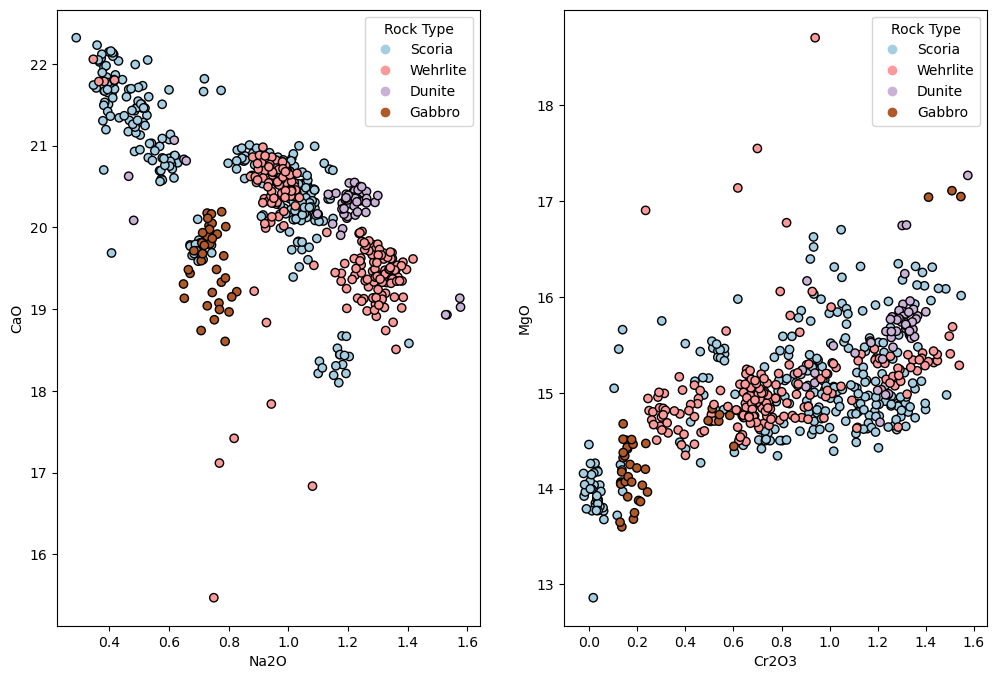

In [242]:

color_map = {'Scoria': 0, 'Wehrlite': 1, 'Dunite': 2, 'Gabbro': 3}

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

scatter= axes[0].scatter(data['Na2O_Cpx'], data['CaO_Cpx'], c=data['Type'].map(color_map), cmap='Paired', ec='k')


axes[0].set_xlabel('Na2O'); axes[0].set_ylabel('CaO')


axes[1].scatter(data['Cr2O3_Cpx'], data['MgO_Cpx'], c=data['Type'].map(color_map), cmap='Paired', ec='k')

handles, _ = scatter.legend_elements()

axes[0].legend(handles, color_map.keys(), title="Rock Type")
axes[1].legend(handles, color_map.keys(), title="Rock Type")

axes[1].set_xlabel('Cr2O3'); axes[1].set_ylabel('MgO')

plt.show()


There are some separate clustering diffrences for Na2O vs CaO.

    Scoria clsuter at high CaO >21, low Na2O <0.6:
    These are crystals that crystalized from hot Ca mafic melt at low pressure. A hight consentration of Cao is typical to see from basaltic melt.

    Wehrlite cluster at CaO 19-20, higher Na2O 1.2-1.4:
    The higher Na2O content indicates a crystalixation at higher pressure, while the lower CaO suggest a orgin from a mantle xenolith.

    Overlapping clusters at Ca 20-21:
    This constitutes the largest part of the clusters. The scoria crystals looks more like xenolith clinopyroxene, indicating that xenolith was picked up rather than crystlized from the orgin melt. 
 

Second plot Cr2O3 vs MgO:
    overlapping clusters - hard to distinguish the gruops
    Scoria at Cr203 - 0:
    Low Cr indicates high pressure crystallization from a mature melt.
    
    Gabbro clustering  Cr2O3- 0.2, Mg0 - 14:
    gabbroic xenoliths formed by cumulate crystallization


There is hard to tell the the obvious differences 

We'll now create a filtered DataFrame including only the chemical data (i.e., removing all the sample information). We're doing this so that we can apply a standard scaling to our data before performing PCA or cluster analysis. The `StandardScaler` class of `sklearn` will transform and normalize the data in each column of our DataFrame according to the equation:

$$ X_{new} = \frac{x - \mu}{sd} $$

where $x$ is the original data, $\mu$ is the mean of the data, and $sd$ is the standard deviation in the dataset.

In [227]:
### Create a filtered DataFrame by taking all the columns after (and including) SiO2_Cpx
filt_data = data.loc[:, 'SiO2_Cpx':].copy()

# Apply the standard scaling to the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(filt_data)

Now we have scaler data, we can perform principal component analysis (PCA). PCA reduced the 'dimensionality' of the data and can help to visualize difference between groups. We can also analyze the PCA data to examine which variables (or combination of variables) are controlling the distribution of compositions within a dataset.

**(10 points)** Complete the code cell below to perform PCA on the scaled dataset. Plot PCA component 1 against PCA components 2 and 3 using the matplotlib subplot functions and color the data by the `Type`. Are we starting to see clear differences between the groups?

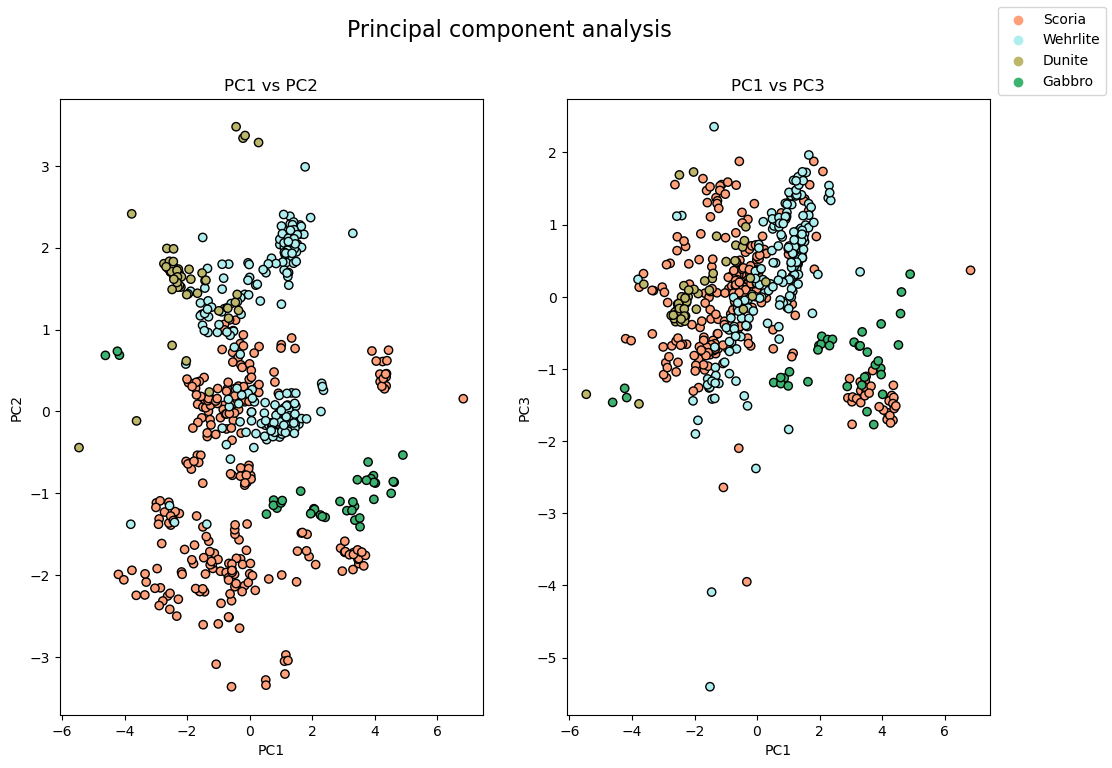

array([0.44866948, 0.25013151, 0.10710727])

In [243]:
# Apply PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_scaled)

# Plot the results
color_map = {'Scoria': 'lightsalmon', 'Wehrlite': 'paleturquoise', 'Dunite': 'darkkhaki', 'Gabbro': 'mediumseagreen'}
c = data['Type'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].scatter(data_pca[:,0],data_pca[:,1], c=c , ec='k')
axes[0].set_title('PC1 vs PC2')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(data_pca[:,0],data_pca[:,2], c=c, ec='k')
axes[1].set_title('PC1 vs PC3')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC3')

for rock_type in color_map.keys():
    axes[0].scatter([], [], color=color_map[rock_type], label=rock_type)

fig.legend(loc='upper right', ncol=1)
fig.suptitle('Principal component analysis', fontsize=16)
plt.show()



pca.explained_variance_ratio_

For the data set, the maximum variance across samples are AL2O3, then Na2O and no CaO.
PC1 is more dominated by mafic rich elements. So low PC1 = Mg/Cr primative mantle like, high PC1 = Fe, Al rich
PC2 is domiated by Na2O => trade off: high pressure cryztallation/ lower pressdure
PC3 is dominated by CaO => trade off: magmatic differentiationes / melt evolution

PC1 vs PC2: wide Scoria spread -> variable Al/ Mg crysylized in diffrent depth/presssure zones
Wherlie: Clusters showing high pressure cryztallation (higer Na2O/ positive PC2)
Dunite: Clusters showing high pressure cryztallation (higer Na2O/ positive PC2)
Gabbro: neagtive PC2 -> orgin from a low pressure zone, positive PC1 -> Al/Fe rich 

Scoria overlaps especialy with Wehrlite, meaning some Scoria crystals have xenolith like chemistry.

PC1 vs PC3:

positive PC3 -> clinopyroxene crystallisingn from rich CaO melt that are primitive and undifferentiated magma
lower PC3 -> high FeOt and high SiO. clinopyroxene from a more evolved Fe rich melt. later-stage differentiation

the plot looks like one unsorted blob. this tells us that differentiation state varies continuously across all rock types, and is therfore not cleanly seperated. 


In the cell below we can make a new DataFrame, this time with the oxides as the index and PC1, PC2, and PC3 as the column headers. Each value in the DataFrame represents the PCA loadings, i.e., the contribution of that element to the variance in that principal component. Higher absolute values indicate a higher contribution to that principal component.

**(5 points)** What pair of elements represent the strongest contribution to the variance of each PC?

For PC1, the strongest contribution to the variance is AL2O3
For PC2, the strongest contribution to the variance is Na2O
For PC3, the strongest contribution to the variance is CaO

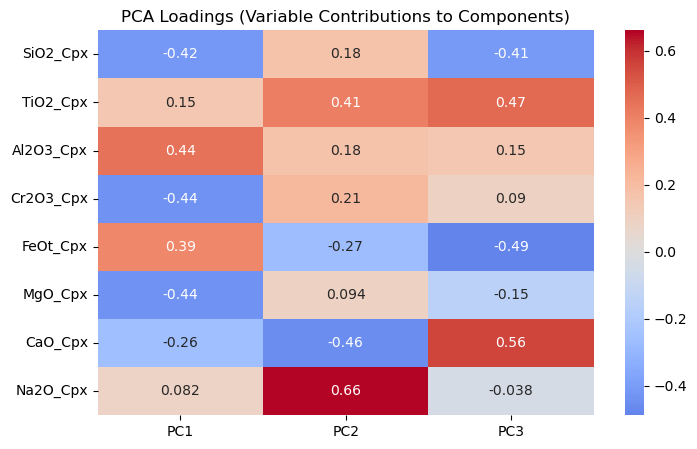

In [229]:
# Get loadings (a.k.a. component weights)
loadings = pca.components_.T  # shape: (n_features, n_components)

# Optionally create a DataFrame for readability
loading_df = pd.DataFrame(loadings, 
                          columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                          index=filt_data.columns) 

plt.figure(figsize=(8, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Loadings (Variable Contributions to Components)')
plt.show()

## Exercise 3 - Clustering

**K-means clustering** is an unsupervised machine learning algorithm used to group similar data points into K distinct clusters based on their features.

Key Steps:
1. Choose K: Decide the number of clusters (K).
2. Initialize centroids: Randomly select K points as initial cluster centers.
3. Assign clusters: Each data point is assigned to the nearest centroid based on distance (usually Euclidean).
4. Update centroids: Calculate the new centroids as the mean of all points in each cluster.
5. Repeat: Steps 3 and 4 are repeated until the centroids stop changing significantly or a maximum number of iterations is reached.

Goal:
Minimize the within-cluster sum of squares (WCSS)—the variance within each cluster.

Pros:
- Simple and fast.
- Works well with large datasets.

Cons:
- Must predefine K.
- Sensitive to outliers and initial centroids.
- Assumes clusters are spherical and equally sized.

**(10 points)** In the cell below use `KMeans` class from `sklearn` to create n clusters from the clinopyroxene data (used the scaled data NOT the PCA scores). Try using different numbers of clusters to see how this affects the data, but for much of the following code I will assume we've used 4 clusters (as we have 4 groups in our loaded data).

In [230]:
# Apply K-Means
kmeans = KMeans(n_clusters=4)
kmeans_labels = kmeans.fit_predict(data_scaled)

kmeans_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3,
       3, 1, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 3, 3, 0, 0, 3, 3, 3, 3, 3,
       3, 3, 3, 0, 3, 3, 3, 0, 0, 0, 0, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 2, 1, 1, 1, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3,
       3, 3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 3,
       3, 3, 3, 3, 3, 0, 0, 0, 1, 1, 1, 3, 3, 3, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

**(5 points)** Plot any combination of oxides and color by the cluster labels. Try plotting different oxide combinations. What parameters (oxides) or combination of parameters appear to be defining each cluster?

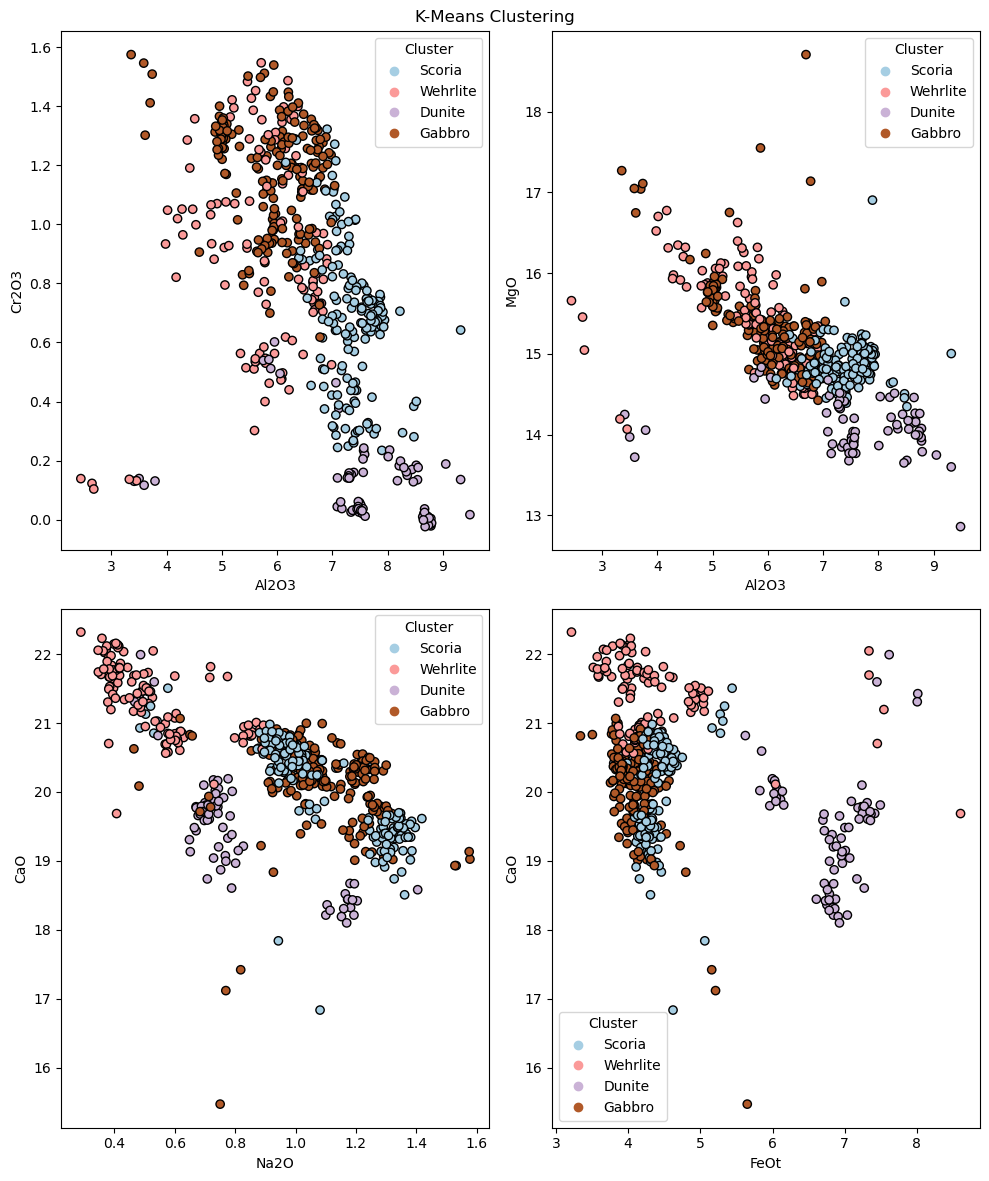

In [241]:
color_map = {'Scoria': 0, 'Wehrlite': 1, 'Dunite': 2, 'Gabbro': 3}

fig, axes = plt.subplots(2, 2, figsize=(10, 12))

sc = axes[0,0].scatter(filt_data['Al2O3_Cpx'], filt_data['Cr2O3_Cpx'], c=kmeans_labels, cmap='Paired',ec='k')
axes[0,0].set_xlabel('Al2O3'); axes[0,0].set_ylabel('Cr2O3') 

axes[0,1].scatter(filt_data['Al2O3_Cpx'], filt_data['MgO_Cpx'], c=kmeans_labels, cmap='Paired', ec='k')
axes[0,1].set_xlabel('Al2O3'); axes[0,1].set_ylabel('MgO')

axes[1,0].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=kmeans_labels, cmap='Paired', ec='k')
axes[1,0].set_xlabel('Na2O'); axes[1,0].set_ylabel('CaO')

axes[1,1].scatter(filt_data['FeOt_Cpx'], filt_data['CaO_Cpx'], c=kmeans_labels, cmap='Paired', ec='k')
axes[1,1].set_xlabel( 'FeOt'); axes[1,1].set_ylabel('CaO')

handles, _ = sc.legend_elements()
for ax in axes.flat:
    ax.legend(handles, color_map.keys(), title="Cluster")

fig.suptitle('K-Means Clustering')

plt.tight_layout()
plt.show()

The separate are more clear along the x-axis FeOt. Higher FeOt > 6 content sepreates Scoria to its own cluster. Range of TiO2 at the same FeOt, Wherelite overlaps with Gabbro for lower TiO2 content, and with Dunite for higher TiO2 content. Now it is easier to look at the differences in crystallization pressure and source rock type.

**Hierarchical Clustering** is an unsupervised learning method that builds a hierarchy of clusters based on the distance (Euclidean Distance) between clusters.

Types:
1. Agglomerative (Bottom-Up) – Most common
- Start with each data point as its own cluster.
- Iteratively merge the closest pair of clusters.
- Stop when all points are in one cluster or a stopping criterion is met.

2. Divisive (Top-Down) – Less common
- Start with all points in one cluster.
- Recursively split clusters into smaller ones.

Steps (Agglomerative):
- Compute the distance matrix between all data points.
- Merge the two closest clusters.
- Update the distance matrix.
- Repeat until one cluster remains or a desired number of clusters is reached.

Linkage Methods (How distance between clusters is measured):
- Single linkage: Min distance between elements of each cluster.
- Complete linkage: Max distance.
- Average linkage: Average pairwise distance.
- Ward’s method: Minimize variance increase.

Output:
- Often visualized as a dendrogram (tree-like diagram).
- You can "cut" the dendrogram at a certain height to form clusters.

**(10 points)** Do the same for hierachical clustering using the `AgglomerativeClustering` class from `sklearn`. Plot up the results. In your view is KMeans of hierachical clustering doing 'better' (this is a very subjective question)? The standard linkage method applied here it 'Ward's Method' (see lecture).

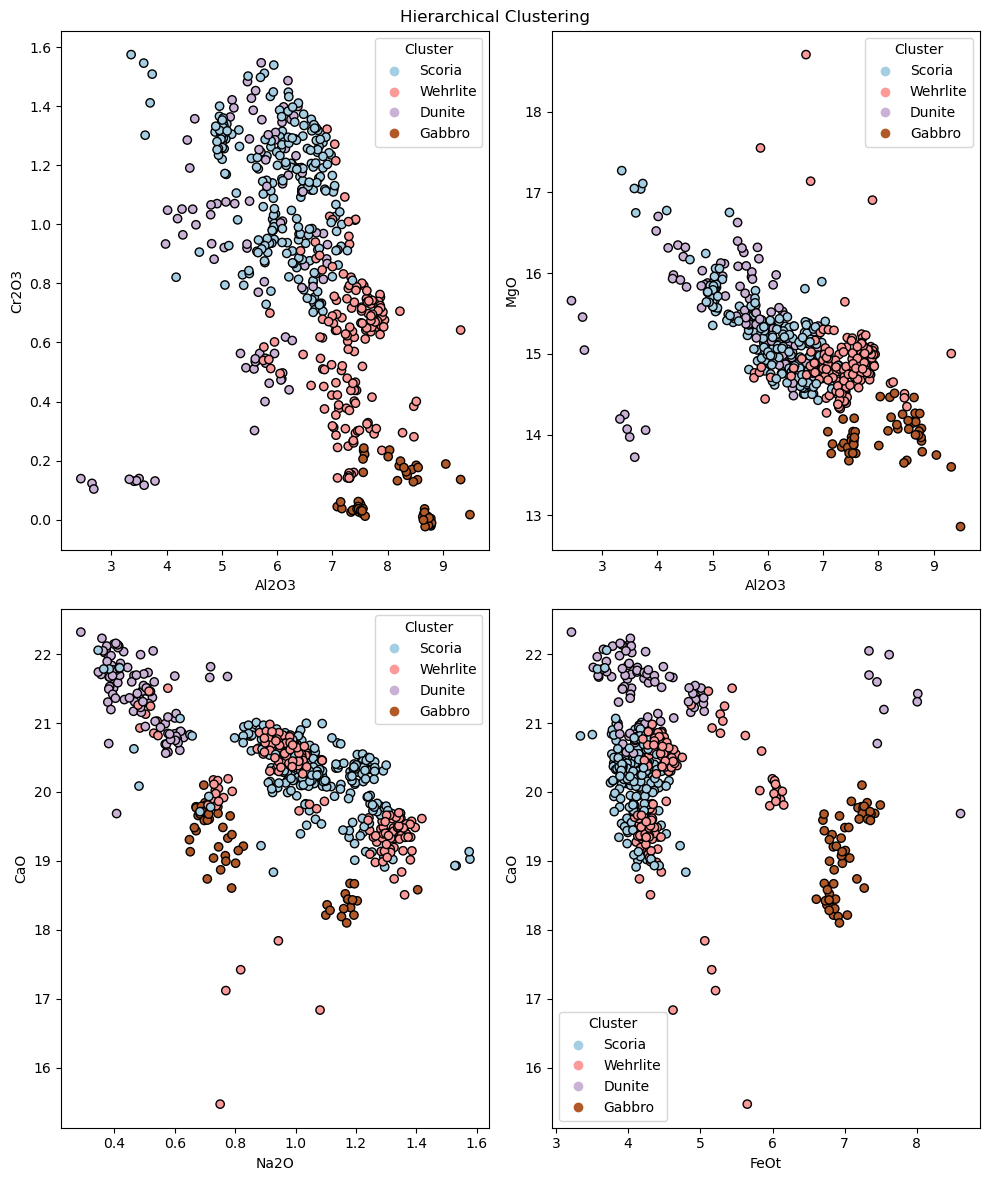

In [240]:
# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(data_scaled)

fig, axes = plt.subplots(2, 2, figsize=(10, 12))

sc = axes[0,0].scatter(filt_data['Al2O3_Cpx'], filt_data['Cr2O3_Cpx'], c=hierarchical_labels, cmap='Paired', ec='k')
axes[0,0].set_xlabel('Al2O3'); axes[0,0].set_ylabel('Cr2O3') 

axes[0,1].scatter(filt_data['Al2O3_Cpx'], filt_data['MgO_Cpx'], c=hierarchical_labels, cmap='Paired', ec='k')
axes[0,1].set_xlabel('Al2O3'); axes[0,1].set_ylabel('MgO')

axes[1,0].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=hierarchical_labels, cmap='Paired', ec='k')
axes[1,0].set_xlabel('Na2O'); axes[1,0].set_ylabel('CaO')

axes[1,1].scatter(filt_data['FeOt_Cpx'], filt_data['CaO_Cpx'], c=hierarchical_labels, cmap='Paired',ec='k')
axes[1,1].set_xlabel( 'FeOt'); axes[1,1].set_ylabel('CaO')

handles, _ = sc.legend_elements()
for ax in axes.flat:
    ax.legend(handles, color_map.keys(), title="Cluster")

fig.suptitle('Hierarchical Clustering')


plt.tight_layout()
plt.show()

The most notable difference between the two methods is a systematic reassignment of samples between the Scoria and Gabbro clusters. In K-means, the high Al2O3 group with moderate to high Cr2O3 is classified as Gabbro, while hierarchical clustering reassigns these same points to Scoria. This pattern is consistent across all four plots. In Al2O3 vs MgO, samples with intermediate Al2O3 content are labelled Gabbro by K-means but Scoria by hierarchical clustering. The same switch appears in Na2O vs CaO, where higher CaO samples are assigned to Gabbro under K-means but to Scoria under hierarchical clustering.

This which places them on the boundary between melt crystallised and crustal xenolith 

It looks like hierarchical clustering does a better job onn this dataset. The hierarchical clustering preserves the Al2O3 and Cr2O3 diffrences for Scoria and Gabbro. The K-mean over assign the samples to Gabbro that geochemically are more like Scoria. For identifying magmatic clinopyroxenes vs xenolith derived crystals, the hierarchical clustering does a better job

As indicated above one of the best ways to visualize hierarchical clustering is with a Dendrogram. This represents a visualization of the distance between clusters on the y axis and demonstrates how the grouping might change if you increase the number of clusters.

**(10 points)** Complete the code below to create and plot a dendrogram using the `linkage` method from `scipy` make sure to specify `method = 'ward'` so that this is equivalent to what we did above. Then use the `dendogram` function to plot these results.

We selected 4 clusters. Does this seem appropriate given the dendogram below?

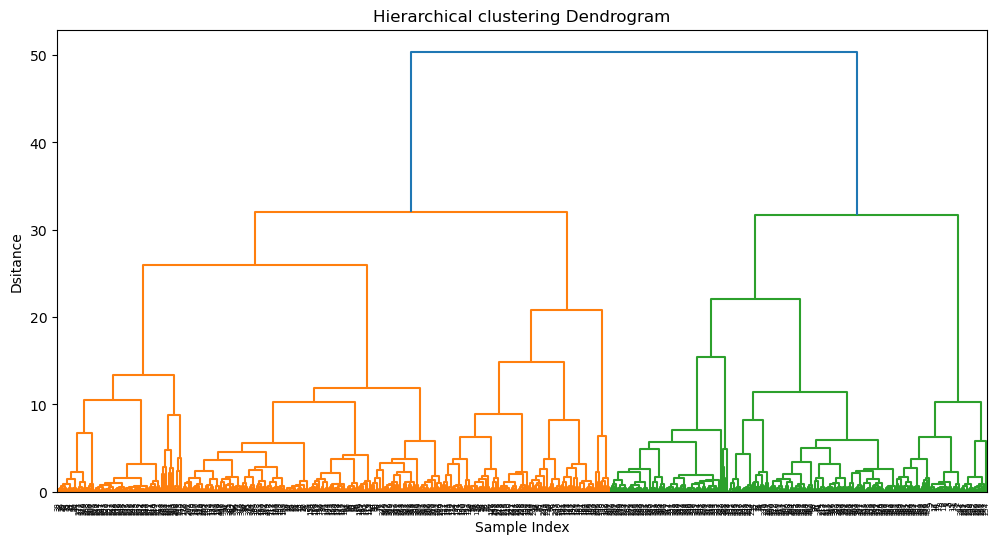

In [233]:
# Compute the linkage matrix
linked = linkage(data_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram( linked, orientation='top',distance_sort='descending', show_leaf_counts=False)

plt.title('Hierarchical clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Dsitance')
plt.show()

The distance of the merge tells how seperare / how diffrent the two cluster are when they merge. Each branch represents to clusters merging.
The biggest merge (blue) seperate the largers chemical diffrense -> 2  distinct chemical populations in the data. each of them splits into two braches each. Which gives 4 distigusing 'big' groups total, making n_clusters = 4 a good fit. 

Form the exercise above, I would guess the big blue split is most likely PC1 -> the Al2O3/MgO/Cr2O3 axis (mantle vs crustal chemistry)
and the internal splits within each supergroup are likely PC2 -> Na2O vs CaO  (pressure) and PC3 -> CaO vs FeOt  (melt evolution)exerc

The final clustering approach we will consider (although you don't have to write any new code) is **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** an unsupervised clustering algorithm that groups together points that are closely packed (dense regions) and labels points in low-density regions as noise/outliers.

Key Concepts:
- ε (epsilon): Radius that defines the neighborhood around a point.
- MinPts: Minimum number of points required to form a dense region (cluster).
- Core Point: Has at least MinPts within ε.
- Border Point: Has fewer than MinPts within ε but is in the neighborhood of a core point.
- Noise Point: Neither a core nor a border point.

Steps:
- For each point, check how many neighbors it has within ε.
- If it's a core point, start a new cluster and expand it by connecting it to neighboring core/border points.
- Continue until all points are visited.

Pros:
- No need to specify number of clusters in advance.
- Can find arbitrarily shaped clusters.
- Identifies outliers/noise.
- Works well with clusters of varying shapes and sizes.

Cons:
- Choice of ε and MinPts is crucial and sometimes tricky.
- Struggles with varying densities.
- Not ideal for high-dimensional data.

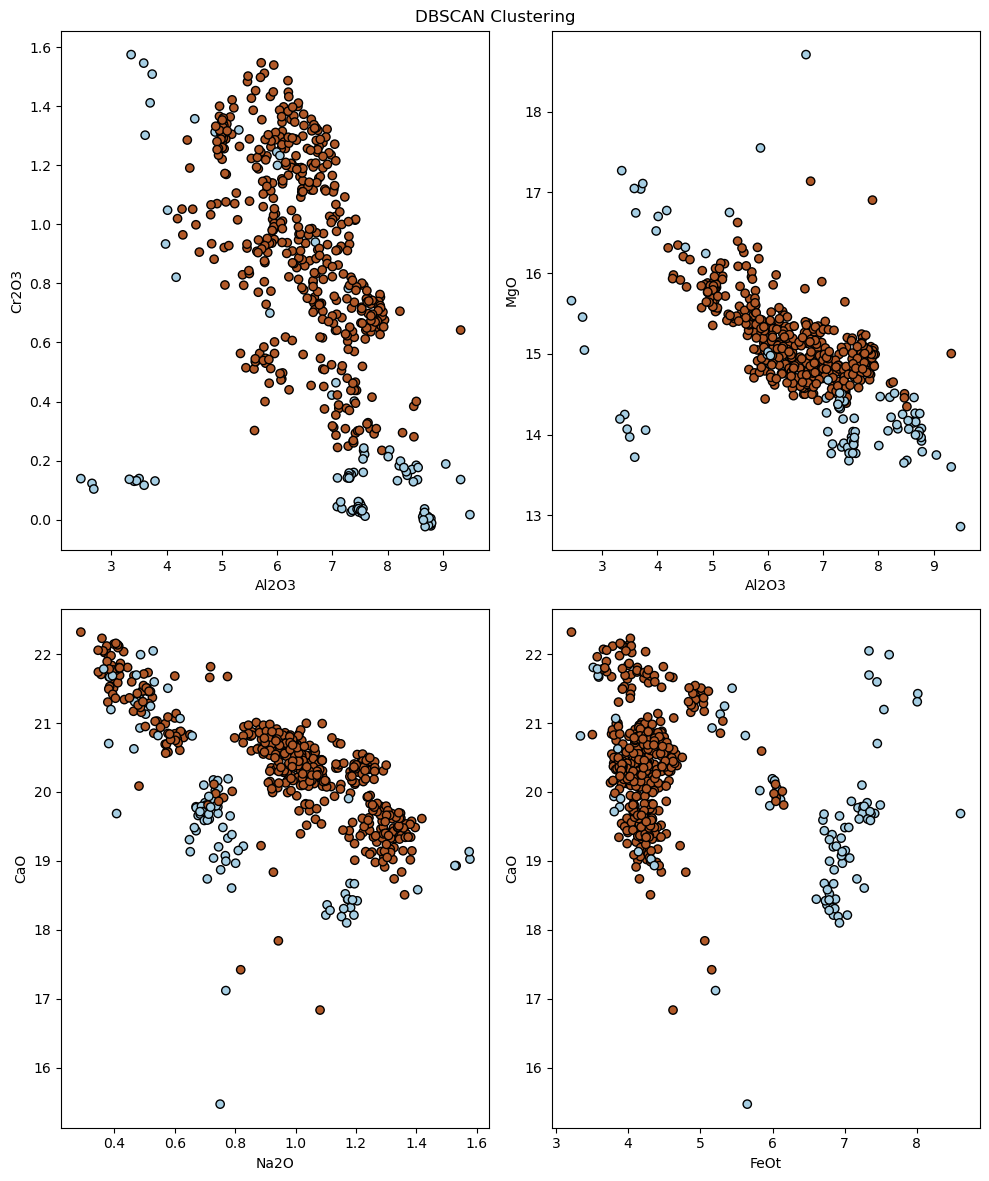

In [244]:
# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=50)
dbscan_labels = dbscan.fit_predict(data_pca)


fig, axes = plt.subplots(2, 2, figsize=(10, 12))

sc = axes[0,0].scatter(filt_data['Al2O3_Cpx'], filt_data['Cr2O3_Cpx'], c=dbscan_labels, cmap='Paired', ec='k')
axes[0,0].set_xlabel('Al2O3'); axes[0,0].set_ylabel('Cr2O3') 

axes[0,1].scatter(filt_data['Al2O3_Cpx'], filt_data['MgO_Cpx'], c=dbscan_labels, cmap='Paired', ec='k')
axes[0,1].set_xlabel('Al2O3'); axes[0,1].set_ylabel('MgO')

axes[1,0].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=dbscan_labels, cmap='Paired', ec='k')
axes[1,0].set_xlabel('Na2O'); axes[1,0].set_ylabel('CaO')

axes[1,1].scatter(filt_data['FeOt_Cpx'], filt_data['CaO_Cpx'], c=dbscan_labels, cmap='Paired', ec='k')
axes[1,1].set_xlabel( 'FeOt'); axes[1,1].set_ylabel('CaO')

# handles, _ = sc.legend_elements()
# for ax in axes.flat:
#     ax.legend(handles, color_map.keys(), title="Cluster")

fig.suptitle('DBSCAN Clustering')

plt.tight_layout()
plt.show()


Only showing two distinct groups. The paramteres is sat to have a radius of 1.5 and a samlpe of 50. to form clusters 50 data points is needed in a radius os 1.5. For this data this onlygives 2 clusters. 

#### BONUS
**Try applying these different clustering methods to the PCA components rather than the scaled data. How does this change the results?**

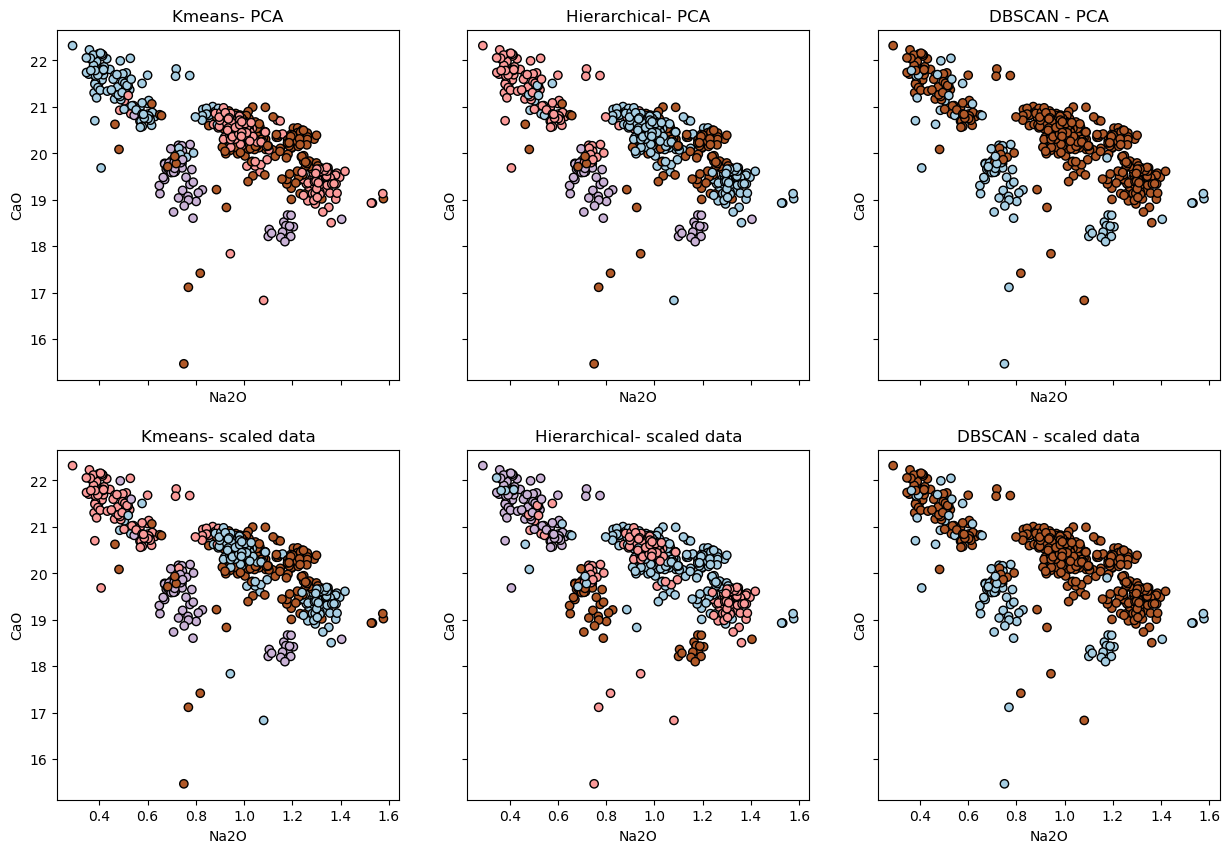

In [235]:

kmeans_pca = KMeans(n_clusters=4)
kmeans_pca_labels = kmeans_pca.fit_predict(data_pca)

hierarchical_pca = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_pca_labels = hierarchical_pca.fit_predict(data_pca)

dbscan_pca = DBSCAN(eps=1.5, min_samples=50)
dbscan_pca_labels = dbscan_pca.fit_predict(data_pca)

fig, ax = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

ax[0,0].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=kmeans_pca_labels, cmap='Paired', ec='k')
ax[0,0].set_title('Kmeans- PCA')


ax[0,1].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=hierarchical_pca_labels, cmap='Paired', ec='k')
ax[0,1].set_title('Hierarchical- PCA')

ax[0,2].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=dbscan_pca_labels, cmap='Paired', ec='k')
ax[0,2].set_title('DBSCAN - PCA')

ax[1,0].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=kmeans_labels, cmap='Paired', ec='k')
ax[1,0].set_title('Kmeans- scaled data')

ax[1,1].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=hierarchical_labels, cmap='Paired', ec='k')
ax[1,1].set_title('Hierarchical- scaled data')

ax[1,2].scatter(filt_data['Na2O_Cpx'], filt_data['CaO_Cpx'], c=dbscan_labels, cmap='Paired', ec='k')
ax[1,2].set_title('DBSCAN - scaled data')


for k in range(3):
    ax[1,k].set_xlabel('Na2O')
    ax[0,k].set_xlabel('Na2O')

for t in range(3):
    ax[0,t].set_ylabel('CaO')
    ax[1,t].set_ylabel('CaO')
  

plt.show()



Applying clustering to PCA components produces notably differenses between the diffrent approches.

K-Means:
The cluster assignments are nearly inverted between the two approaches. The pink becomes purple and vice versa, and the blue becomes brown and vice versa. For the scaled data, all of the oxides contribute equally. When clustering on the PCA components, the dominant variance becomes the main mechanism driving the clustering. This shows the sensitivity of k-means

Hierarchical clustering:
For Hierarchical clustering the difference isant as inverted at the kmeans, but there are promenent reclustering between the two approches. the high CaO region shows some reassignment of clusters between methods.

DBSCAN:
the DBSCAN produces Simmialr results, making the result unchanged. This tells us that the  density threshold is so strict for both PCA components and the scaled data

## Exercise 4 - Comparing clusters to initial classifications

**(20 points)** In the space below create histograms for each `Type` in the original dataset showing the proportion of samples from each `Type` that belong to each of the three (or n) cluster identified by the K-means, Hierarchical, and DBSCAN clustering performed above. I've provided the code to do this for K-means clustering results, try and do the same for the other two methods. 

When looking at these results also try to calculate determine which method is most effective at isolating crystals that originate from the wehrlite or gabbro xenoliths.

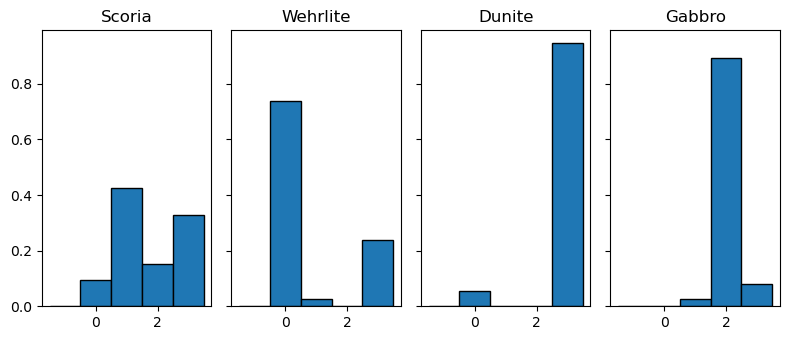

In [236]:
# Histrograms for K-means clustering
types = data['Type'].unique()

f, a = plt.subplots(1,len(types), figsize = (8, 3.5), sharey = True)
for idx, t in enumerate(types):
    a[idx].hist(kmeans_labels[data['Type'] == t], bins = np.arange(-1.5, 4.5, 1), 
                edgecolor = 'k', density = True)
    a[idx].set_title(t)


f.tight_layout()
#

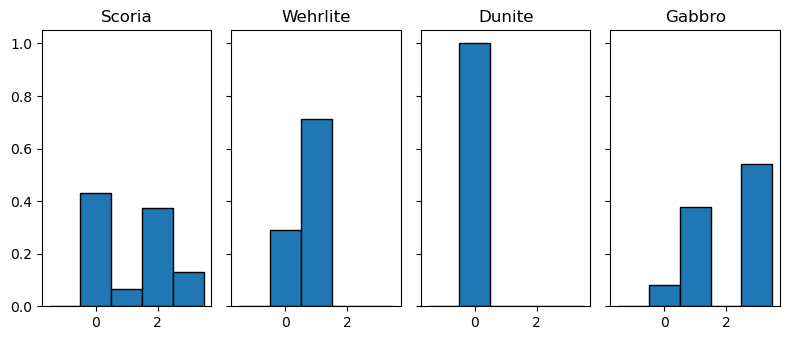

In [237]:
# Do the same for Hierarchical clustering
types = data['Type'].unique()

f, a = plt.subplots(1,len(types), figsize = (8, 3.5), sharey = True)
for idx, t in enumerate(types):
    a[idx].hist(hierarchical_labels[data['Type'] == t], bins = np.arange(-1.5, 4.5, 1), 
                edgecolor = 'k', density = True)
    a[idx].set_title(t)


f.tight_layout()

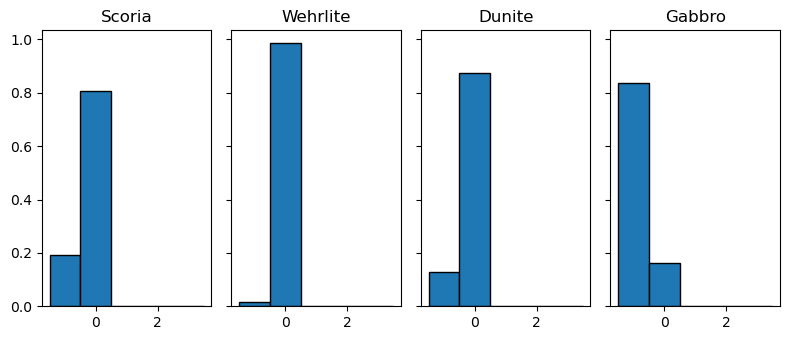

In [238]:

# And for DBSCAN
types = data['Type'].unique()
f, a = plt.subplots(1,len(types), figsize = (8, 3.5), sharey = True)
for idx, t in enumerate(types):
    a[idx].hist(dbscan_labels[data['Type'] == t], bins = np.arange(-1.5, 4.5, 1), 
                edgecolor = 'k', density = True)
    a[idx].set_title(t)


f.tight_layout()

We can now examine the final results

**(10 points)** Plot histograms for the pressure (P_kbar) for the cluster that best represents data that does NOT originate from one of the xenolith groups. Plot 2 histograms, one for the results of K-means clustering and one for the results of hierarchical clustering. Plot only the samples that are initially defined as "Scoria" and fall into the chosen cluster

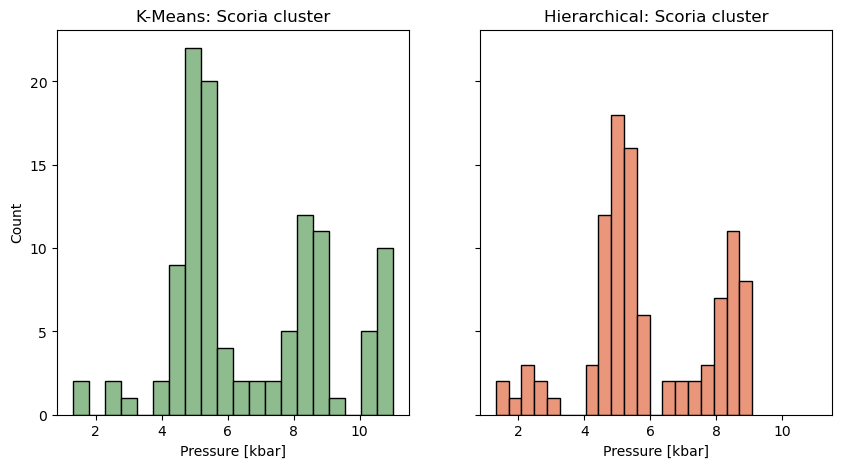

In [246]:

kmeans_scoria = 1
hierarchical_scoria= 2
kmeans_mask = (data['Type'] == 'Scoria') & (kmeans_labels == kmeans_scoria)
hier_mask = (data['Type'] == 'Scoria') & (hierarchical_labels == hierarchical_scoria)



f, a = plt.subplots(1,2, figsize = (10,5), sharey=True, sharex=True)


a[0].hist(data.loc[kmeans_mask,'P_kbar'], bins=20, edgecolor='k', color= 'darkseagreen')
a[0].set_title('K-Means: Scoria cluster')
a[0].set_xlabel('Pressure [kbar]')
a[0].set_ylabel('Count')

a[1].hist(data.loc[hier_mask,'P_kbar'], bins=20, edgecolor='k', color='darksalmon')
a[1].set_title('Hierarchical: Scoria cluster')
a[1].set_xlabel('Pressure [kbar]')

plt.show()


**(10 points)** Write a brief discussion about the clustering results and what this means for the pressure of magma storage beneath Floreana (remember the crust-mantle boundary, the Moho) is found at a pressure of ~450 MPa.


Both K-means and hierarchical scoria clusters show peak in crystallization pressures between 4–6 kbar, this is around the Moho pressure of 4.5 kbar. This means that the magma beneath Floreana was mostly stored relativly near the crust-mantle boundary. This align with the consept of buoyancy: where magma rises through the mantle, it slows down and stalls near the Moho when it hits the less dense oceanic crust, creating a storage zone. This is consistent with the pressure peak seen in both histograms. The K-means cluster shows a broader bimodal pressure distribution extending from 1- 11 kbar, while he hierechial is more tighlty concentrated around 4–6 kbar. This indicates a better isolation of crystals that grew  during magma accumulation at the Moho. This aslo supports the conclusion from Exercise 3 where it was argued that hierarchical clustering more effective separated magmatic clinopyroxenes from xenolith-derived crystals.